### Import packages

In [44]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
import seaborn as sns 
from sklearn.metrics import mean_absolute_error,mean_squared_error 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import LinearSVR
from sklearn.linear_model import SGDRegressor

minX = -601
maxX = 600
tStepSize = 25

### Get the file with the recording that we want

In [45]:
folder_path = "C:/Users/ryanb/Documents/GitHub/Foraging_Data/Test-PI/" # 'FelixData/'
dir_scalar = folder_path + "scalars_14336_0.csv" # "scalars_10240_0.csv"
dir_hstates = folder_path + "hstates_14336_0.csv" # "hstates_10240_0.csv"

### Merge files and get longest id dataFrame

In [46]:
def merge_files(file_path, file_path_scalar):
    # Reading the CSV files
    df = pd.read_csv(file_path, header=None)
    df_scalar = pd.read_csv(file_path_scalar, low_memory=False)

    # Renaming the columns as "Node i"
    df.columns = [f"Node {i}" for i in range(1, df.shape[1] + 1)]
    
    df_scalar = df_scalar[df_scalar['player_position_x'] != 'player_position_x']
    merged_df = pd.concat([df_scalar.reset_index(drop=True), df.reset_index(drop=True)], axis=1)

    return merged_df

df = merge_files(dir_hstates, dir_scalar)
most_common_episode_id = df['episode_id'].mode()[0]
episode_df = df[df['episode_id'] == most_common_episode_id]
episode_df['player_position_x'] = episode_df['player_position_x'].str.split('.').str[0].astype(int)
episode_df['player_position_y'] = episode_df['player_position_y'].str.split('.').str[0].astype(int)
episode_df['delta_x'] = episode_df['delta_x'].str.split('.').str[0].astype(int)
episode_df['delta_y'] = episode_df['delta_y'].str.split('.').str[0].astype(int)

C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\3315494947.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  episode_df['player_position_x'] = episode_df['player_position_x'].str.split('.').str[0].astype(int)
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\3315494947.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  episode_df['player_position_y'] = episode_df['player_position_y'].str.split('.').str[0].astype(int)
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\3315494947.py:19: SettingWithCopyW

# Relative Displacement

### Preprosessing step for relative displacement

In [47]:
def preprocess(steps, df_merged):
    # Calculate delta values for future steps
    df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
    df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    print(df_merged['delta_X'].unique())
    return df_merged

df_merged = preprocess(10, episode_df)

[  5.   6.   7.   8.   9.  10.   4.   3.   2.   1.   0.  -1.  -2.  -3.
  -4.  -5.  -6.  -7.  -8.  -9. -10.]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


### Fitting models for relative displacement

In [48]:
def correlate(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['delta_X', 'delta_Y']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 

    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    #model_kernel = LinearSVR(epsilon=0.0, tol=0.0001, C=1.0, loss='epsilon_insensitive', 
    #                                           fit_intercept=True, intercept_scaling=1.0, dual=False, verbose=0,
    #                                           random_state=None, max_iter=1000) # KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    
    model_kernel = KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)#  SGDRegressor(max_iter=1000, tol=1e-3) #
    
    model_kernel.fit(X_train, y_train)
    
    return model1, model, X_test, y_test, model_kernel


### Finding RMSE and score of the different methods for relative displacement

In [49]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []

# store the models before running the code!!!!
for i in range(minX,maxX,tStepSize):
    df_merged = preprocess(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate(df_merged)
    all_data.append([model1, model, model_kernel])
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test),squared=False) )
    scores_ridge.append(model.score(X_test, y_test))
    RMSE_ridge.append(mean_squared_error(y_true=y_test,y_pred=model.predict(X_test),squared=False) )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test),squared=False) )
    naive.append(mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test),squared=False) )

C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


[-19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.
  -5.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.   7.   9.  10.
  12.  14.  15.  17.  19.  20.  21.  22.  23.  24.  25.  26.  18.  16.
  13.  11.   8.  27.  28.  29.  30.  31.  32.  33.  34.  35.  36.  38.
  40.  41.  42.  43.  44.  45.  39.  37.  46.  47.  48.  49.  50.  51.
  52.  53.  54.  -4. -20. -21. -22. -23. -24. -25. -26. -27. -28. -29.
 -30. -31. -32. -33. -34. -35. -36. -37. -38. -39. -40. -41. -42. -43.
 -44. -45. -46. -47. -48.  55.  57.  59.  61.  62.  63.  64.  58.  56.
 -49. -50. -51. -52. -53. -54. -55. -56. -57. -58. -59. -60. -61. -62.
 -63. -64.  60.  65.  67.  66. -65. -67. -68. -69. -70. -71. -72. -73.
 -74. -75. -76. -77. -78. -79. -66.  68.  69.  70.  71.  72.  73.  74.
  75.  76.  77.  78.  79.  80.  81.  82.  83.  84.]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


[-22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -10.  -9.  -7.
  -6.  -5.  -4.  -3.  -1.   0.   1.   3.   4.   5.   6.   7.   8.   9.
  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  21.  22.  23.  24.
  25.  26.  27.  28.  29.  30.  32.  34.  35.  36.  37.  38.  33.  20.
   2.  31.  39.  40.  41.  42.  43.  44.  -2.  -8. -11. -23. -24. -25.
 -26. -27. -28. -29. -30. -31. -32. -33. -34. -35. -36. -37. -38. -39.
  45. -40. -41. -42. -43. -44. -45. -46. -47. -48.  46.  47.  48.  49.
  50. -49. -50. -51. -52. -53. -54. -55. -56. -57. -58. -59. -60. -61.
 -62. -63. -64. -65. -66. -67.  51.  52.  54.  55.  57.  58.  60.  61.
  62.  63.  64.  65.  66.  67.  68.  69.  70.  59.  56.  53. -68. -69.
 -70. -71. -72. -73. -74. -75. -76. -77. -78. -79.  71.  72.  73.  74.
  75.  76.  77.  78. -80. -81. -82.]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


...

[ 22.  21.  20.  19.  18.  17.  16.  15.  14.  13.  12.  11.  10.   9.
   8.   7.   6.   5.   4.   3.   2.   1.   0.  -1.  -2.  -3.  -4.  -5.
  -6.  -7.  -8.  -9. -10. -11. -12. -14. -16. -18. -19. -20. -21. -22.
 -23. -25. -26. -27. -29. -30. -31. -32. -33. -34. -35. -24. -17. -15.
 -13. -28. -36. -37. -38. -39. -40. -41. -42. -43. -44.  23.  24.  25.
  26.  27.  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.
 -45.  40.  41.  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.
  53. -47. -49. -50. -52. -53. -54. -55. -56. -57. -48. -46.  54.  56.
  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  55. -51. -58.
 -59. -60. -61. -62. -63. -64. -65. -66. -67. -68. -69. -70.  68.  69.
  70.  71.  72.  73.  74.  75.  76. -72. -73. -74. -75. -71. -76. -77.
 -78.  77.  78.  79.  80.  81.]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


[ 22.  21.  20.  19.  18.  17.  16.  15.  14.  13.  12.  11.   9.   8.
   6.   5.   4.   3.   2.   1.  -1.  -2.  -3.  -5.  -6.  -7.  -8.  -9.
 -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20. -21. -23. -24.
 -25. -26. -27. -28. -29. -30. -31. -33. -34. -35. -37. -38. -36. -32.
 -22.  -4. -39. -40. -41. -42. -43. -44.   0.   7.  10.  23.  24.  25.
  26.  27.  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.
 -45.  40.  41.  42.  43.  44.  45.  46.  47.  48. -46. -47. -48. -49.
 -50. -51.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.
  61.  62.  63.  64.  65.  66.  67. -52. -53. -55. -56. -57. -59. -60.
 -61. -62. -63. -64. -65. -66. -67. -68. -69. -70. -58. -54.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79. -71. -72. -73. -74.
 -75. -76. -77. -78.  80.  81.  82.]


C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_X'] = df_merged['player_position_x'].shift(-steps) - df_merged['player_position_x']
C:\Users\ryanb\AppData\Local\Temp\ipykernel_23276\1671894524.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_merged['delta_Y'] = df_merged['player_position_y'].shift(-steps) - df_merged['player_position_y']


[ 19.  18.  17.  16.  14.  13.  12.  11.  10.   9.   8.   7.   6.   5.
   4.   3.   1.   0.  -1.  -2.  -3.  -4.  -5.  -6.  -7.  -8.  -9. -11.
 -12. -14. -16. -17. -19. -21. -22. -23. -24. -25. -26. -27. -20. -18.
 -15. -10. -13. -28. -29. -30. -32. -33. -34. -36. -38. -39. -40. -41.
 -42. -43. -44. -45. -37. -35. -31. -46. -47. -48. -49. -50. -51. -52.
 -53.   2.  15.  20.  21.  22.  23.  24.  25.  26.  27.  28.  29.  30.
  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.  42.  43.  44.
  45.  46.  47.  48. -55. -56. -57. -59. -60. -61. -62. -63. -64. -58.
 -54.  49.  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.
  62.  63.  64. -66. -68. -67. -65.  65.  66.  67.  68.  69.  70.  71.
  72.  73.  74.  75.  76.  77.  78.  79. -69. -70. -71. -72. -73. -74.
 -76. -77. -78. -79. -80. -81. -82. -83. -75.]


### Plot RMSE and score for relative displacement

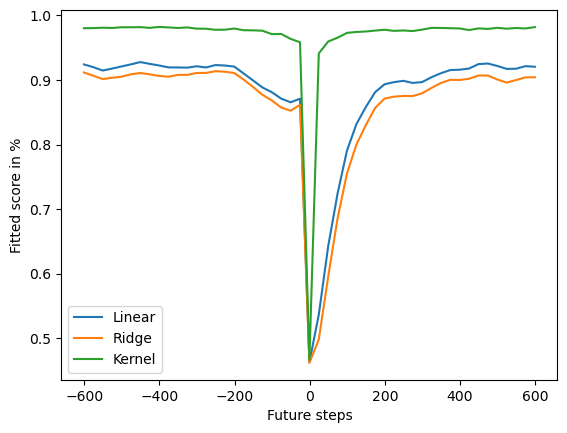

In [55]:
future_list = [i for i in range(minX,maxX,tStepSize)]
plt.figure(0)
plt.plot(future_list, scores_linear, label= "Linear")
plt.plot(future_list, scores_ridge, label="Ridge")
plt.plot(future_list, scores_kernel, label="Kernel")
plt.legend()
plt.ylabel("Fitted score in %")
plt.xlabel("Future steps")
plt.show()

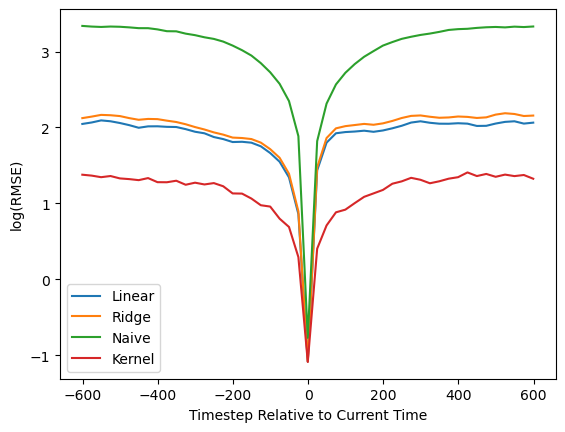

In [57]:
plt.figure(1)
plt.plot(future_list, np.log(np.array(RMSE_linear)), label="Linear")
plt.plot(future_list, np.log(np.array(RMSE_ridge)), label="Ridge")
plt.plot(future_list, np.log(np.array(naive)), label="Naive")
plt.plot(future_list, np.log(np.array(rmse_kernel)), label="Kernel")
plt.legend()
plt.ylabel("log(RMSE)")
plt.xlabel("Timestep Relative to Current Time")
plt.show()

### Store data from run in file

In [58]:
import pickle

# After running the for loop
data_to_store = {
    'scores_linear': scores_linear,
    'RMSE_linear': RMSE_linear,
    'scores_ridge': scores_ridge,
    'RMSE_ridge': RMSE_ridge,
    'naive': naive,
    'scores_kernel': scores_kernel,
    'rmse_kernel': rmse_kernel,
    'all_data': all_data
}

# Save the data to a file
with open('models_data_pathInt.pkl', 'wb') as f:
    pickle.dump(data_to_store, f)

### Get data back

In [55]:
with open('models_data_1.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

# Access the lists like this:
scores_linear = loaded_data['scores_linear']
RMSE_linear = loaded_data['RMSE_linear']
scores_ridge = loaded_data['scores_ridge']
RMSE_ridge = loaded_data['RMSE_ridge']
naive = loaded_data['naive']
scores_kernel = loaded_data['scores_kernel']
rmse_kernel = loaded_data['rmse_kernel']
print(rmse_kernel)
#all_data = loaded_data['all_data']

[5.613629258016383, 5.496459815517033, 5.486501670634484, 5.180598560624784, 5.107503959885889, 4.9189042612876115, 4.767006230161398, 4.580134659686058, 4.4188289698247445, 4.276887829792914, 4.360934837538907, 4.196674534340905, 3.8006505263761587, 3.7064291231703654, 3.307348576139127, 2.936098593503558, 2.732854134489798, 2.2796523707721885, 1.806646474049586, 1.240194666400997, 0.6049142309428708, 0.7180055846658526, 1.3481404207160264, 1.8853570187850734, 2.2224092463030742, 2.7724289172052528, 2.9838232831249627, 3.2090217991046703, 3.3604252688330565, 3.6692803448768334, 3.8876695499756484, 4.022012145245327, 4.228441380740754, 4.38685349836846, 4.707236944439996, 4.804628244649999, 4.7608493464369985, 4.8983858128545155, 5.224914017970621, 5.237376365828585, 5.289260755407166, 5.310706399534714]


# Displacement from origo

### Preprocess

In [45]:
def preprocess_true_distance(steps, df_merged):

    # Calculate delta values for future steps
    df_merged['delta_X_from_O'] = df_merged['delta_x'].shift(-steps) #- df_merged['player_position_x']
    df_merged['delta_Y_from_O'] = df_merged['delta_y'].shift(-steps)# - df_merged['player_position_y']
    # Remove rows with NaN values resulting from shift
    if steps > 0:
        df_merged = df_merged.iloc[:-steps]
    elif steps < 0:
        df_merged = df_merged.iloc[-steps:]
    else:
        pass  # steps = 0, no shift needed
    print(df_merged['delta_X_from_O'].unique())
    return df_merged

df_merged = preprocess(10, episode_df)

[ -2.  -1.   0.  -3.  -4.  -5.  -6.   2.   4.   6.   7.   8.   9.   5.
   3.   1.  -7.  -8.  -9. -10.  10.]


### Fit models

In [47]:
def correlate_from_O(df_merged):

    # Drop rows with NaN values in 'delta_X' and 'delta_Y'
    y = df_merged[['delta_X_from_O', 'delta_Y_from_O']]
    
    # Align 'df' data to match 'y' dimensions by dropping the last 'future_steps' rows
    features = df_merged[[f'Node {i}' for i in range(1, 513)]]

    X = np.array(features)
    Y = np.array(y)

    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.25) 



    # Linear regression model
    model1 = LinearRegression()
    model1.fit(X_train, y_train)

    # Ridge regression
    model = Ridge(alpha=0.1)
    model.fit(X_train, y_train)

    # Kernel
    

    model_kernel = KernelRidge(alpha=0.1, kernel='rbf', gamma=0.1)
    model_kernel.fit(X_train, y_train)



    
    return model1, model, X_test, y_test, model_kernel

### Store RMSE and score of model fittings

In [48]:
scores_linear = []
RMSE_linear = []
scores_ridge = []
RMSE_ridge = []
naive = []
scores_kernel = []
rmse_kernel = []
all_data = []
# store the models before running the code!!!!
for i in range(-35,36,10):
    df_merged = preprocess_true_distance(i, episode_df)
    model1, model, X_test, y_test, model_kernel = correlate_from_O(df_merged)
    all_data.append([model1, model, model_kernel])
    #analysis(model1, model, X_test, y_test)
    scores_linear.append(model1.score(X_test, y_test))
    RMSE_linear.append(mean_squared_error(y_true=y_test,y_pred=model1.predict(X_test),squared=False) )
    scores_ridge.append(model.score(X_test, y_test))
    RMSE_ridge.append(mean_squared_error(y_true=y_test,y_pred=model.predict(X_test),squared=False) )
    scores_kernel.append(model_kernel.score(X_test, y_test))
    rmse_kernel.append(mean_squared_error(y_true=y_test,y_pred=model_kernel.predict(X_test),squared=False) )
    naive.append(mean_squared_error(y_true=y_test,y_pred=np.zeros_like(y_test),squared=False) )

[ 17.  16.  15.  14.  13.  12.  11.  10.   9.   8.   7.   6.   5.   4.
   3.   2.   1.   0.  -1.  -2.  -3.  -4.  18.  19.  20.  21.  -5.  -6.
  -7.  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36.  35.  36.  37.  38.  39.  40.  41.  42. -37. -38. -39. -40. -41.
 -42. -43. -44. -45. -46. -47.  43.  44.  45.  46.]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

[ 17.  16.  15.  14.  13.  12.  11.  10.   9.   8.   7.   6.   5.   4.
   3.   2.   1.   0.  -1.  -2.  -3.  -4.  18.  19.  20.  21.  -5.  -6.
  -7.  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36.  35.  36.  37.  38.  39.  40.  41.  42. -37. -38. -39. -40. -41.
 -42. -43. -44. -45. -46. -47.  43.  44.  45.  46.]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

[ 17.  16.  15.  14.  13.  12.  11.  10.   9.   8.   7.   6.   5.   4.
   3.   2.   1.   0.  -1.  -2.  -3.  -4.  18.  19.  20.  21.  -5.  -6.
  -7.  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36.  35.  36.  37.  38.  39.  40.  41.  42. -37. -38. -39. -40. -41.
 -42. -43. -44. -45. -46. -47.  43.  44.  45.  46.]


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

[ 15.  14.  13.  12.  11.  10.   9.   8.   7.   6.   5.   4.   3.   2.
   1.   0.  -1.  -2.  -3.  -4.  16.  17.  18.  19.  20.  21.  -5.  -6.
  -7.  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36.  35.  36.  37.  38.  39.  40.  41.  42. -37. -38. -39. -40. -41.
 -42. -43. -44. -45. -46. -47.  43.  44.  45.  46.]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

[ 12.  11.  10.   9.   8.   7.   6.   5.   4.   3.   2.   1.   0.  -1.
  -2.  -3.  -4.  13.  14.  15.  16.  17.  18.  19.  20.  21.  -5.  -6.
  -7.  -8.  -9. -10. -11. -12. -13. -14. -15. -16. -17. -18. -19. -20.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34. -21.
 -22. -23. -24. -25. -26. -27. -28. -29. -30. -31. -32. -33. -34. -35.
 -36.  35.  36.  37.  38.  39.  40.  41.  42. -37. -38. -39. -40. -41.
 -42. -43. -44. -45. -46. -47.  43.  44.  45.  46.]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

### Plot

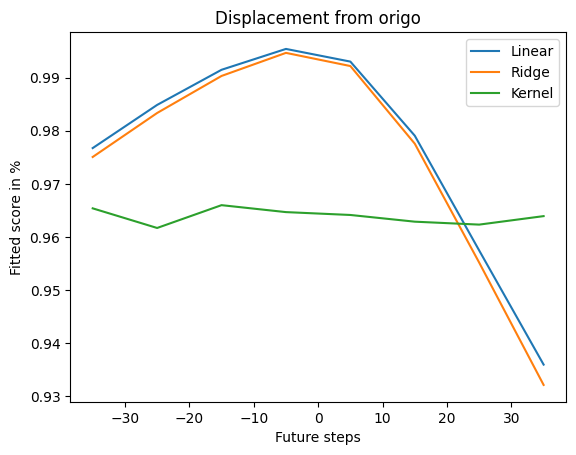

In [54]:
future_list = [i for i in range(-35,36,10)]
plt.figure(0)
plt.title("Displacement from origo")
plt.plot(future_list, scores_linear, label= "Linear")
plt.plot(future_list, scores_ridge, label="Ridge")
plt.plot(future_list, scores_kernel, label="Kernel")
plt.legend()
plt.ylabel("Fitted score in %")
plt.xlabel("Future steps")
plt.show()

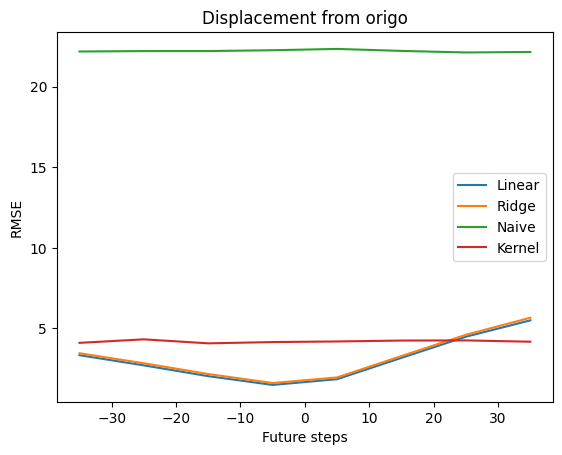

In [52]:
plt.figure(1)
plt.title("Displacement from origo")
plt.plot(future_list, np.array(RMSE_linear), label="Linear")
plt.plot(future_list, np.array(RMSE_ridge), label="Ridge")
plt.plot(future_list, np.array(naive), label="Naive")
plt.plot(future_list, np.array(rmse_kernel), label="Kernel")
plt.legend()
plt.ylabel("RMSE")
plt.xlabel("Future steps")
plt.show()